# Evaluation of Offering Strategies

In this notebook we will compare the strategies presented in `04-offer_strategies_opis.ipynb`, over all the test period (2026-02-01 to 2026-03-24). We will evaluate their performance given real market and wind outcomes over these days, considering profit and risk. We will also analyse the expected performance of the strategies.


## Load data and generate results

Results can take hours. Hence we generate them once and save them to a file. 

In [1]:
RERUN_RESULTS = False

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_real = pd.read_parquet('../generated_scenarios/real_outcomes.parquet')

in_sample_scenarios = {}
out_of_sample_scenarios = {}
dates = df_real.index.get_level_values(0).strftime("%Y-%m-%d").unique()
for date in dates:
     scenarios = np.load(f'../generated_scenarios/scenarios_{date}.npy')
     in_sample_scenarios[date] = scenarios[:,:800,:]
     out_of_sample_scenarios[date] = scenarios[:,800:,:]

var_names = {'OffshoreWindPower': 'Offshore Wind Production (MW)', 
             'SpotPriceEUR': 'Spot Price (EUR/MWh)', 
             'DominatingDirection': 'Imbalance Direction (1, 0, -1)', 
             'ImbalancePriceEUR': 'Imbalance Price (EUR/MWh)'}

x_axis = df_real.index

In [3]:
# generate or load results
if RERUN_RESULTS:
    from src.market import DayEvaluator, OnePriceModel, TwoPriceModel
    results = {date:[] for date in dates}
    ALPHA_CVAR = 0.95
    for date in dates:
        df_real_date = df_real.loc[date].copy()

        if len(df_real_date) != 96:
            print(f"Warning: Date {date} has {len(df_real_date)} hours instead of 96. Skipping this date.")
            continue

        day_evaluator = DayEvaluator(date=date,
                                imbalance_settlement='one_price',
                                scenarios=in_sample_scenarios[date],
                                df_real=df_real_date)
        
        
        # Strategy 1 Forecasted day-ahead offer
        p_da = df_real_date['ForecastDayAhead'].values
        evaluation = day_evaluator.evaluate_strategy(p_DA = p_da,
                                                    strategy_id='day_ahead_forecast',
                                                    strategy_name='Offer Day-ahead forecast',
                                                    others={},
                                                    alpha_CVaR=ALPHA_CVAR)
        results[date].append(evaluation)

        # Strategy 2 Expected value offer
        p_da = in_sample_scenarios[date][0,:,:].mean(axis=0)
        evaluation = day_evaluator.evaluate_strategy(p_DA = p_da,
                                                    strategy_id='expected_value_offer',
                                                    strategy_name='Offer Expected Value',
                                                    others={},
                                                    alpha_CVaR=ALPHA_CVAR)
        results[date].append(evaluation)

        # Strategy 3 Production-quantile offer
        quantiles = [0.25, 0.4, 0.6, 0.75]

        for tau in quantiles:
            p_da = np.quantile(in_sample_scenarios[date][0,:,:], tau, axis=0)
            evaluation = day_evaluator.evaluate_strategy(p_DA = p_da,
                                                        strategy_id=f'quantile_{tau}',
                                                        strategy_name=f'Offer {int(tau*100)}% Quantile',
                                                        others={'tau': tau},
                                                        alpha_CVaR=ALPHA_CVAR)
            results[date].append(evaluation)

        # Strategy 4 Stochastic offer for One Price Model
        alphas = [0.9, 0.975]
        betas = [0.75, 1]
        beta0 = 0

        # first fit for beta=0 (no risk management)
        one_price_model = OnePriceModel(in_sample_scenarios[date], P_max=500)
        one_price_model.fit(beta=beta0)
        evaluation = day_evaluator.evaluate_strategy(p_DA = one_price_model.p_DA_opt,
                                                        strategy_id=f'one_price_beta_{beta0}',
                                                        strategy_name=f'Max Profit and CVaR (No risk management)',
                                                        others={'beta': beta0},
                                                        alpha_CVaR=ALPHA_CVAR)
        
        results[date].append(evaluation)

        for alpa in alphas:
            for beta in betas:
                one_price_model = OnePriceModel(in_sample_scenarios[date], P_max=500)
                one_price_model.fit(beta=beta, alpha=alpa)
                evaluation = day_evaluator.evaluate_strategy(p_DA = one_price_model.p_DA_opt,
                                                            strategy_id=f'one_price_beta_{beta}_alpha_{alpa}',
                                                            strategy_name=f'Max Profit and CVaR (alpha={alpa}, beta={beta})',
                                                            others={'beta': beta, 'alpha': alpa},
                                                            alpha_CVaR=ALPHA_CVAR)
                results[date].append(evaluation)

        
        # Strategy 5 Stochastic offer for Two Price Model, but evaluated in One Price Model

        # first fit for beta=0 (no risk management)
        two_price_model = TwoPriceModel(in_sample_scenarios[date], P_max=500)
        two_price_model.fit(beta=beta0)
        evaluation = day_evaluator.evaluate_strategy(p_DA = two_price_model.p_DA_opt,
                                                        strategy_id=f'two_price_beta_{beta0}',
                                                        strategy_name=f'Max Profit and CVaR Two Price Model (No risk management)',
                                                        others={'beta': beta0},
                                                        alpha_CVaR=ALPHA_CVAR)
        results[date].append(evaluation)

        for alpa in alphas:
            for beta in betas:
                two_price_model = TwoPriceModel(in_sample_scenarios[date], P_max=500)
                two_price_model.fit(beta=beta, alpha=alpa)
                evaluation = day_evaluator.evaluate_strategy(p_DA = two_price_model.p_DA_opt,
                                                            strategy_id=f'two_price_beta_{beta}_alpha_{alpa}',
                                                            strategy_name=f'Max Profit and CVaR Two Price Model (alpha={alpa}, beta={beta})',
                                                            others={'beta': beta, 'alpha': alpa},
                                                            alpha_CVaR=ALPHA_CVAR)
                results[date].append(evaluation)


    # save results object
    import pickle
    with open('../results/strategy_evaluation_results.pkl', 'wb') as f:
        pickle.dump(results, f)
else:
    # load results object
    import pickle
    with open('../results/strategy_evaluation_results.pkl', 'rb') as f:
        results = pickle.load(f)

### Format and summarise results

In [4]:
import dataclasses

# Fields that are arrays — keep them out of the flat DataFrame
_EXCLUDE = {'p_DA', 'profit_per_scenario', 'details'}

records = [
    {'date': date, **{k: v for k, v in dataclasses.asdict(r).items() if k not in _EXCLUDE}}
    for date, strats in results.items()
    for r in strats
]

df_results = pd.DataFrame(records).dropna(subset=['profit_real'])

df_results['date'] = pd.to_datetime(df_results['date'])

def format_label(s):
    s = s.replace("alpha_", "α=").replace("beta_", "β=")
    s = s.replace("_", " ").replace("one price", "Mean-CVaR").replace("two price", "Mean-CVaR Two Price")
    s = s.replace("quantile", "Quantile").replace("day ahead forecast", "Day-Ahead Forecast")
    s = s.replace("expected value offer", "Expected Value Offer")
    return s

df_results["label"] = df_results["strategy_id"].apply(format_label)

In [11]:
# Compute summary statistics per strategy
# Total profit, mean profit, stdev, VaR_95, CVaR_95, profit_to_risk (mu/stdev)
result_summary = (
    df_results.groupby("strategy_id")
    .agg(
        total_profit=("profit_real", "sum"),
        mean_profit=("profit_real", "mean"),
        stdev_profit=("profit_real", "std"),
        mean_exposure_to_imbalance=("exposure_to_imbalance", "mean"),
        VaR_95=("profit_real", lambda x: np.percentile(x, 5)),
        CVaR_95=("profit_real", lambda x: np.mean(x[x <= np.percentile(x, 5)])),
        profit_to_risk=("profit_real", lambda x: np.mean(x) / np.std(x) if np.std(x) > 0 else np.nan),
        avg_expected_profit=("expected_profit", "mean"),
        avg_expected_exposure_to_imbalance=("expected_exposure", "mean"),
        avg_expected_std=("stdev_profit", "mean"),
        n_days=("date", "nunique")
    )
)

result_summary["label"] = result_summary.index.map(format_label)
result_summary = result_summary.sort_values("total_profit", ascending=False).reset_index(drop=True)

## Evaluate real outcomes

Here we want to answer:

- Which strategy profitted the most from the real market and wind outcomes?
- How balance is each strategy in terms of profit and risk? 
- Which is the best if we consider risk aversion?

### Total profits

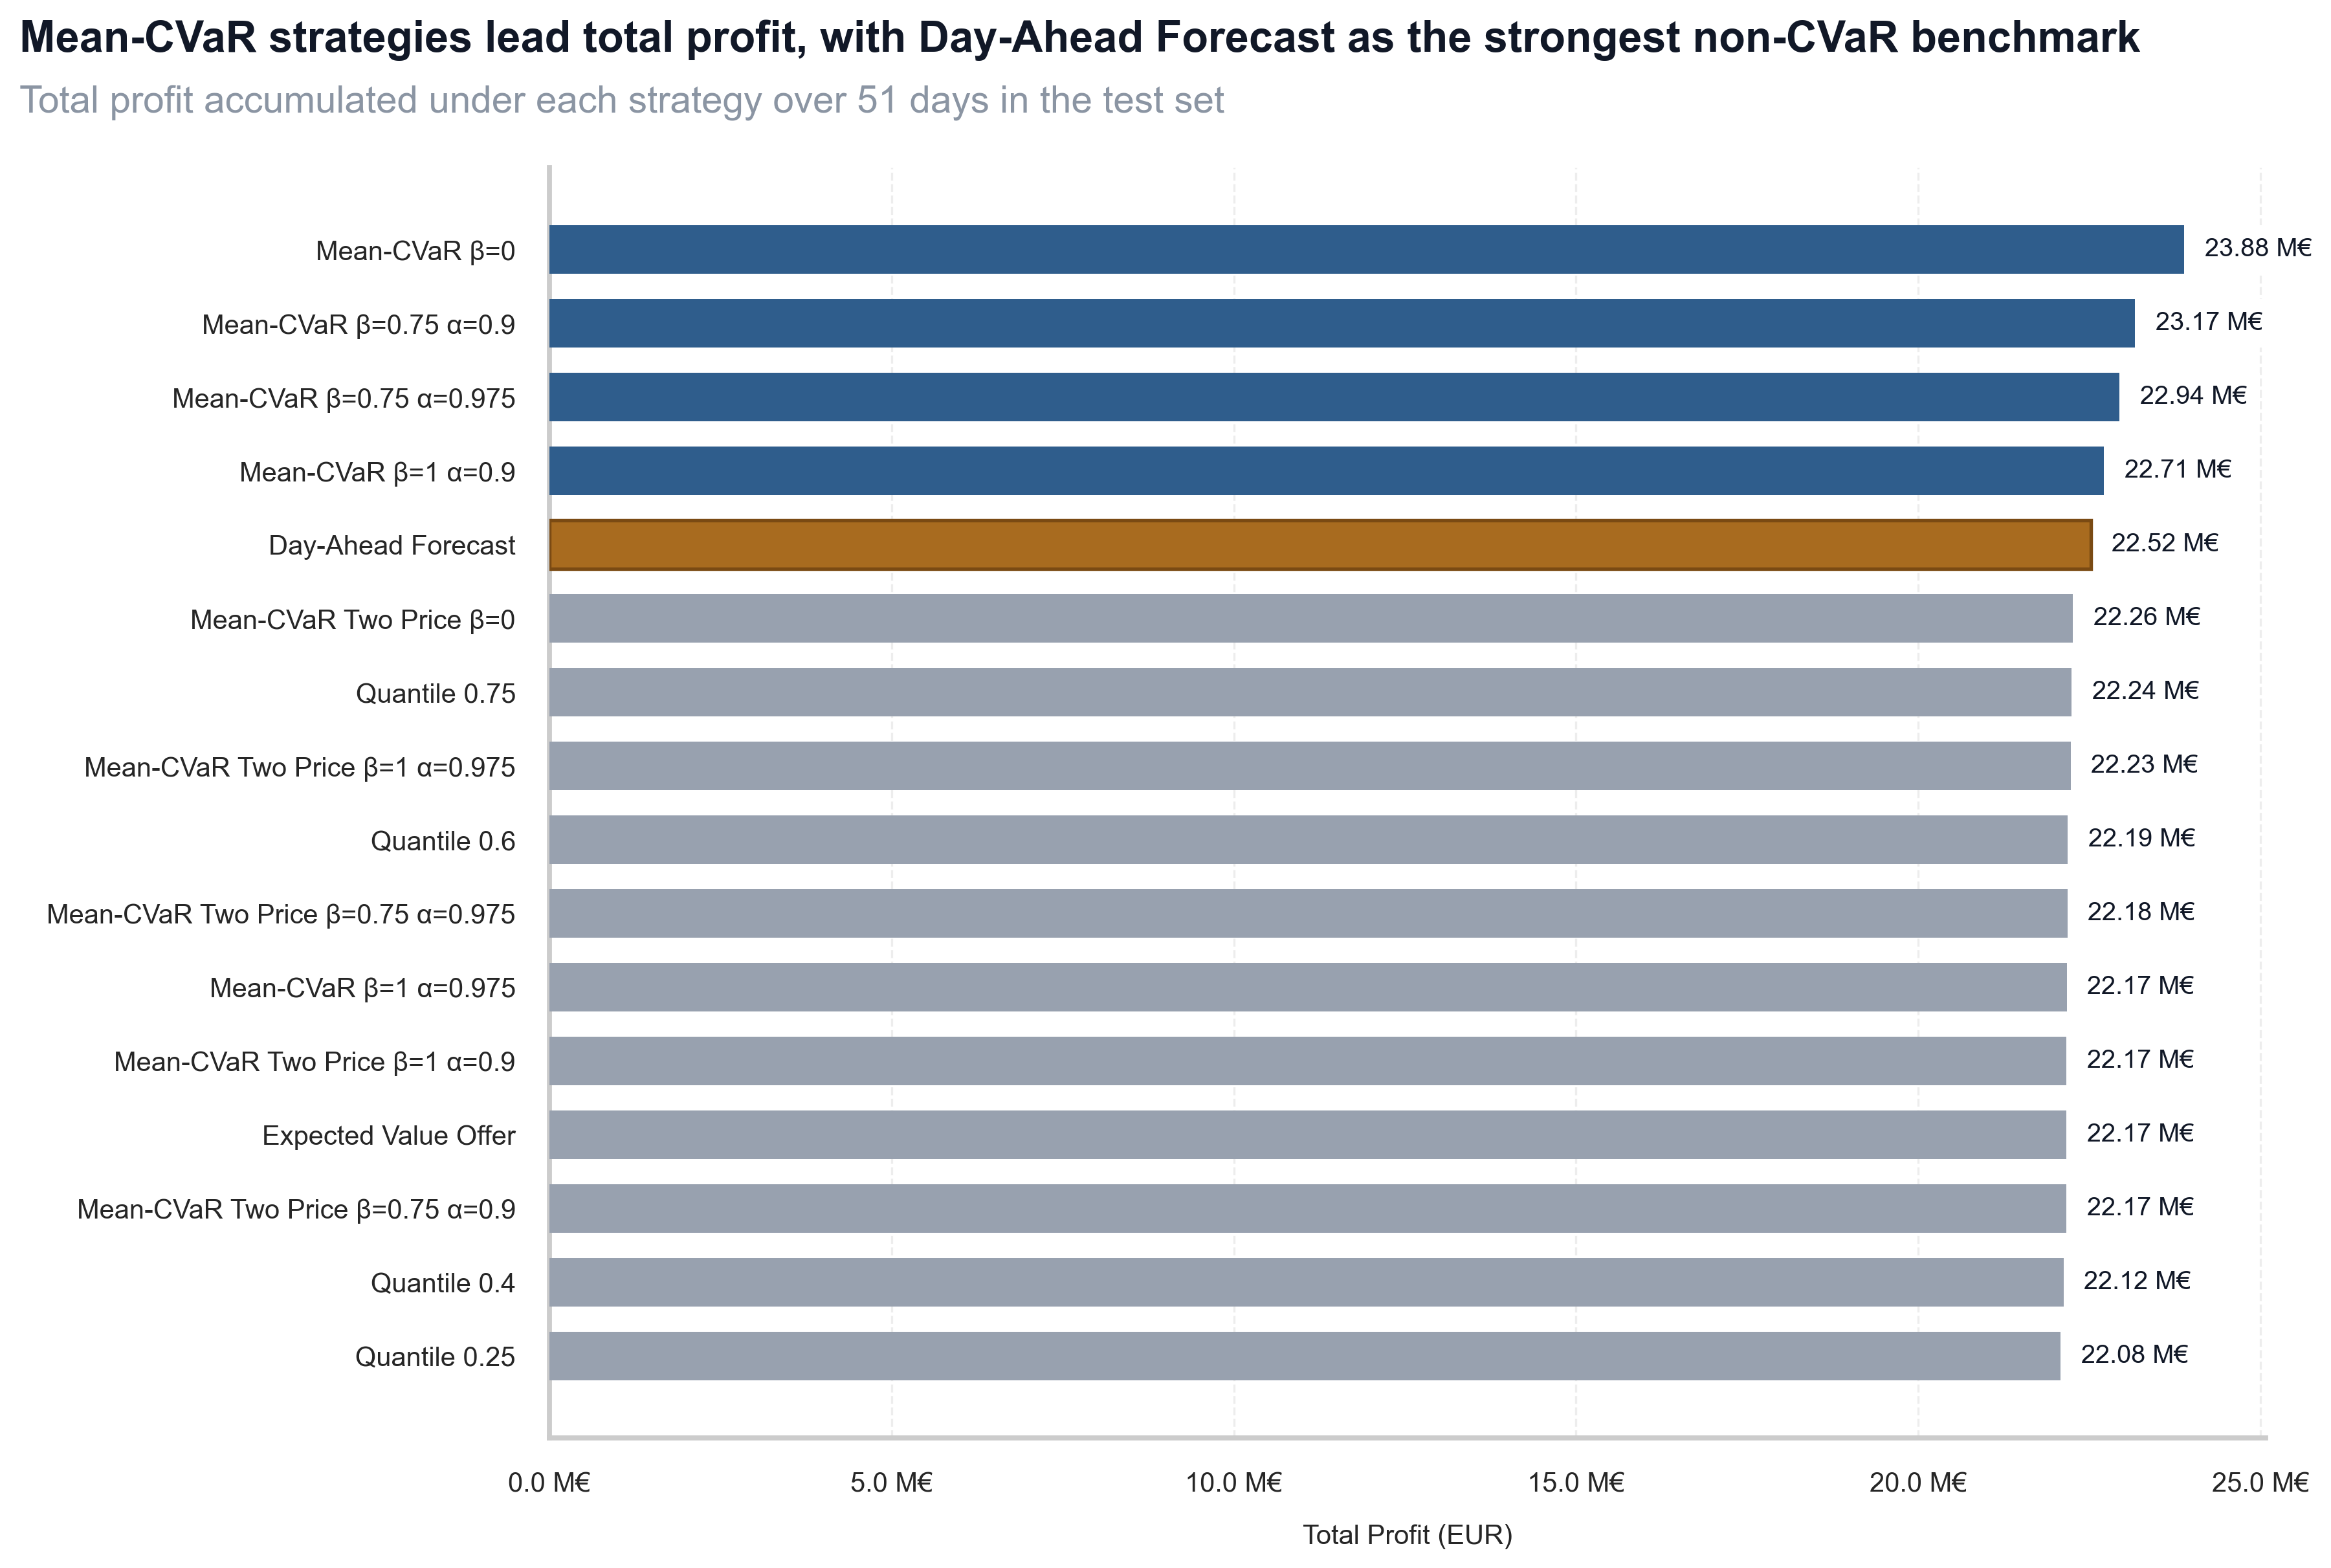

In [28]:
# Plot total profit by strategy
from matplotlib.ticker import FuncFormatter

TITLE = "Mean-CVaR strategies lead total profit, with Day-Ahead Forecast as the strongest non-CVaR benchmark"
SUBTITLE = "Total profit accumulated under each strategy over 51 days in the test set"

sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(13, 8.5), dpi=300)

labels = result_summary["label"].tolist()
profits = result_summary["total_profit"].values

# Increase vertical spacing between rows for cleaner label readability
row_spacing = 1.18
y_pos = np.arange(len(result_summary)) * row_spacing
bar_height = 0.78

# Highlight all strategies ranked above Day-Ahead Forecast and Day-Ahead itself
is_day_ahead = result_summary["label"].str.contains("Day-Ahead Forecast", case=False, na=False)
day_ahead_idx = int(np.where(is_day_ahead)[0][0]) if is_day_ahead.any() else len(result_summary) - 1
highlight_mask = np.arange(len(result_summary)) <= day_ahead_idx

# Professional palette: muted slate for baseline, steel blue for highlighted leaders, bronze for Day-Ahead
base_color = "#98A1AF"
highlight_color = "#2F5D8C"
day_ahead_color = "#A86B1F"

colors = [
    day_ahead_color if i == day_ahead_idx else (highlight_color if highlight_mask[i] else base_color)
    for i in range(len(result_summary))
]

bars = ax.barh(
    y=y_pos,
    width=profits,
    color=colors,
    edgecolor="none",
    height=bar_height,
    zorder=3,
 )

# Add subtle outline to Day-Ahead Forecast bar for emphasis
if is_day_ahead.any():
    bars[day_ahead_idx].set_edgecolor("#7A4A13")
    bars[day_ahead_idx].set_linewidth(1.3)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)
ax.invert_yaxis()

ax.set_xlabel("Total Profit (EUR)", labelpad=10, fontsize=10)
ax.set_ylabel("")

# Keep x-axis tick labels proportional with y-axis labels
ax.tick_params(axis="x", labelsize=10)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1e6:,.1f} M€"))
ax.grid(axis="x", linestyle="--", linewidth=0.8, alpha=0.35, zorder=1)
ax.grid(axis="y", visible=False)

x_min_ax, x_max_ax = ax.get_xlim()
offset = 0.012 * (x_max_ax - x_min_ax)

for bar, val in zip(bars, profits):
    y_center = bar.get_y() + bar.get_height() / 2
    x_right = bar.get_width()
    ax.text(
        x_right + offset,
        y_center,
        f"{val/1e6:,.2f} M€",
        va="center",
        ha="left",
        fontsize=9.5,
        color="#111827",
        backgroundcolor="white",
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Title style aligned with other polished plots
fig.text(
    0.07,
    0.97,
    TITLE,
    ha="left",
    va="top",
    fontsize=16,
    fontweight="bold",
    color="#111827",
)
fig.text(
    0.07,
    0.93,
    SUBTITLE,
    ha="left",
    va="top",
    fontsize=14,
    color="#8B95A3",
)

fig.subplots_adjust(top=0.88, right=0.96, left=0.28)
plt.show()

In [40]:
# Examinate dates where best strategy and worst strategy differs more from day-ahead forecast
top_strategy = result_summary.iloc[0]["label"]
worst_strategy = result_summary.iloc[-1]["label"]

df_results_comparison = df_results[df_results["label"].isin([top_strategy, worst_strategy, "Day-Ahead Forecast"])].copy()
comparison_pt = df_results_comparison.groupby(["date", "label"])["profit_real"].sum().reset_index()
comparison_pt = comparison_pt.pivot(index="date", columns="label", values="profit_real")
comparison_pt["diff_top_day_ahead"] = abs(comparison_pt[top_strategy] - comparison_pt["Day-Ahead Forecast"])
comparison_pt["diff_worst_day_ahead"] = abs(comparison_pt[worst_strategy] - comparison_pt["Day-Ahead Forecast"])

print("Top 10 dates where the best strategy differs the most from Day-Ahead Forecast:")
print(comparison_pt.sort_values("diff_top_day_ahead", ascending=False)[["Day-Ahead Forecast", top_strategy, "diff_top_day_ahead"]].head(10))

print("\nTop 10 dates where the worst strategy differs the most from Day-Ahead Forecast:")
print(comparison_pt.sort_values("diff_worst_day_ahead", ascending=False)[["Day-Ahead Forecast", worst_strategy, "diff_worst_day_ahead"]].head(10))


Top 10 dates where the best strategy differs the most from Day-Ahead Forecast:
label       Day-Ahead Forecast  Mean-CVaR β=0  diff_top_day_ahead
date                                                             
2026-02-10       230956.250601 -644792.982519       875749.233120
2026-03-06       190431.367775  758520.500696       568089.132922
2026-03-04       414034.845809  972750.845314       558715.999505
2026-03-03       434599.860362  958615.439372       524015.579010
2026-02-26       340535.082104 -179252.889927       519787.972031
2026-02-19       103639.881882 -406811.974331       510451.856213
2026-03-16       490580.618711   71733.785394       418846.833317
2026-03-07        54182.423311  445152.055707       390969.632395
2026-02-17       521200.666101  872475.867773       351275.201672
2026-03-05       146602.098120  497210.414142       350608.316022

Top 10 dates where the worst strategy differs the most from Day-Ahead Forecast:
label       Day-Ahead Forecast  Quantile 0.25  d

In [77]:
# select dates to inspect

dates_to_inspect = [
    "2026-02-10",
    "2026-02-17",
    "2026-02-19",
    "2026-02-26",
    "2026-03-03",
    "2026-03-04",
    "2026-03-05",
    "2026-03-06",
    "2026-03-07",
]

# df_real.columns: Index(['OffshoreWindPower', 'ForecastDayAhead', 'TimeDK', 'SpotPriceEUR','ImbalancePriceEUR', 'DominatingDirection'],
# df_real.index  dtype='datetime64[us, UTC]', name='Minutes5UTC', length=5087, freq=None)


df_real['date'] = df_real.index.normalize().strftime("%Y-%m-%d")
inspection_df = df_real[df_real['date'].isin(dates_to_inspect)].copy()

# Inspect average spot price per date, stdev of spot price, average imbalance price, stdev of imbalance price, average offshore wind production, stdev of offshore wind production, average difference between spot price and imbalance price
inspection_df['date'] = inspection_df.index.normalize()
inspection_df["PriceDiff"] = inspection_df["SpotPriceEUR"] - inspection_df["ImbalancePriceEUR"]

inspection_df.groupby("date").agg(
    SpotPriceEUR_mean=("SpotPriceEUR", "mean"),
    SpotPriceEUR_std=("SpotPriceEUR", "std"),
    ImbalancePriceEUR_mean=("ImbalancePriceEUR", "mean"),
    ImbalancePriceEUR_std=("ImbalancePriceEUR", "std"),
    OffshoreWindPower_mean=("OffshoreWindPower", "mean"),
    OffshoreWindPower_std=("OffshoreWindPower", "std"),
    PriceDiff_mean=("PriceDiff", "mean"),
)

,SpotPriceEUR_mean,SpotPriceEUR_std,ImbalancePriceEUR_mean,ImbalancePriceEUR_std,OffshoreWindPower_mean,OffshoreWindPower_std,PriceDiff_mean
date,,,,,,,
2026-02-10 00:00:00+00:00,191.784479,76.945396,305.932708,222.615977,93.561016,43.367663,-114.148229
2026-02-17 00:00:00+00:00,183.076042,133.827758,138.188854,160.741214,113.798809,53.949270,44.887188
2026-02-19 00:00:00+00:00,169.610521,101.124503,213.306042,353.050498,32.187178,19.297893,-43.695521
2026-02-26 00:00:00+00:00,75.096771,16.852408,143.827812,412.294180,331.449505,123.814869,-68.731042
2026-03-03 00:00:00+00:00,107.294687,45.750083,41.594792,142.711929,169.094529,43.199326,65.699896
2026-03-04 00:00:00+00:00,146.497813,77.891761,82.108437,84.857061,119.666752,93.329453,64.389375
2026-03-05 00:00:00+00:00,118.331875,41.823882,83.837396,62.345220,45.388104,49.447090,34.494479
2026-03-06 00:00:00+00:00,125.570937,45.547367,68.135937,116.375255,54.209430,25.382197,57.435000
2026-03-07 00:00:00+00:00,119.053021,35.535069,83.871875,66.707736,11.819533,11.731330,35.181146


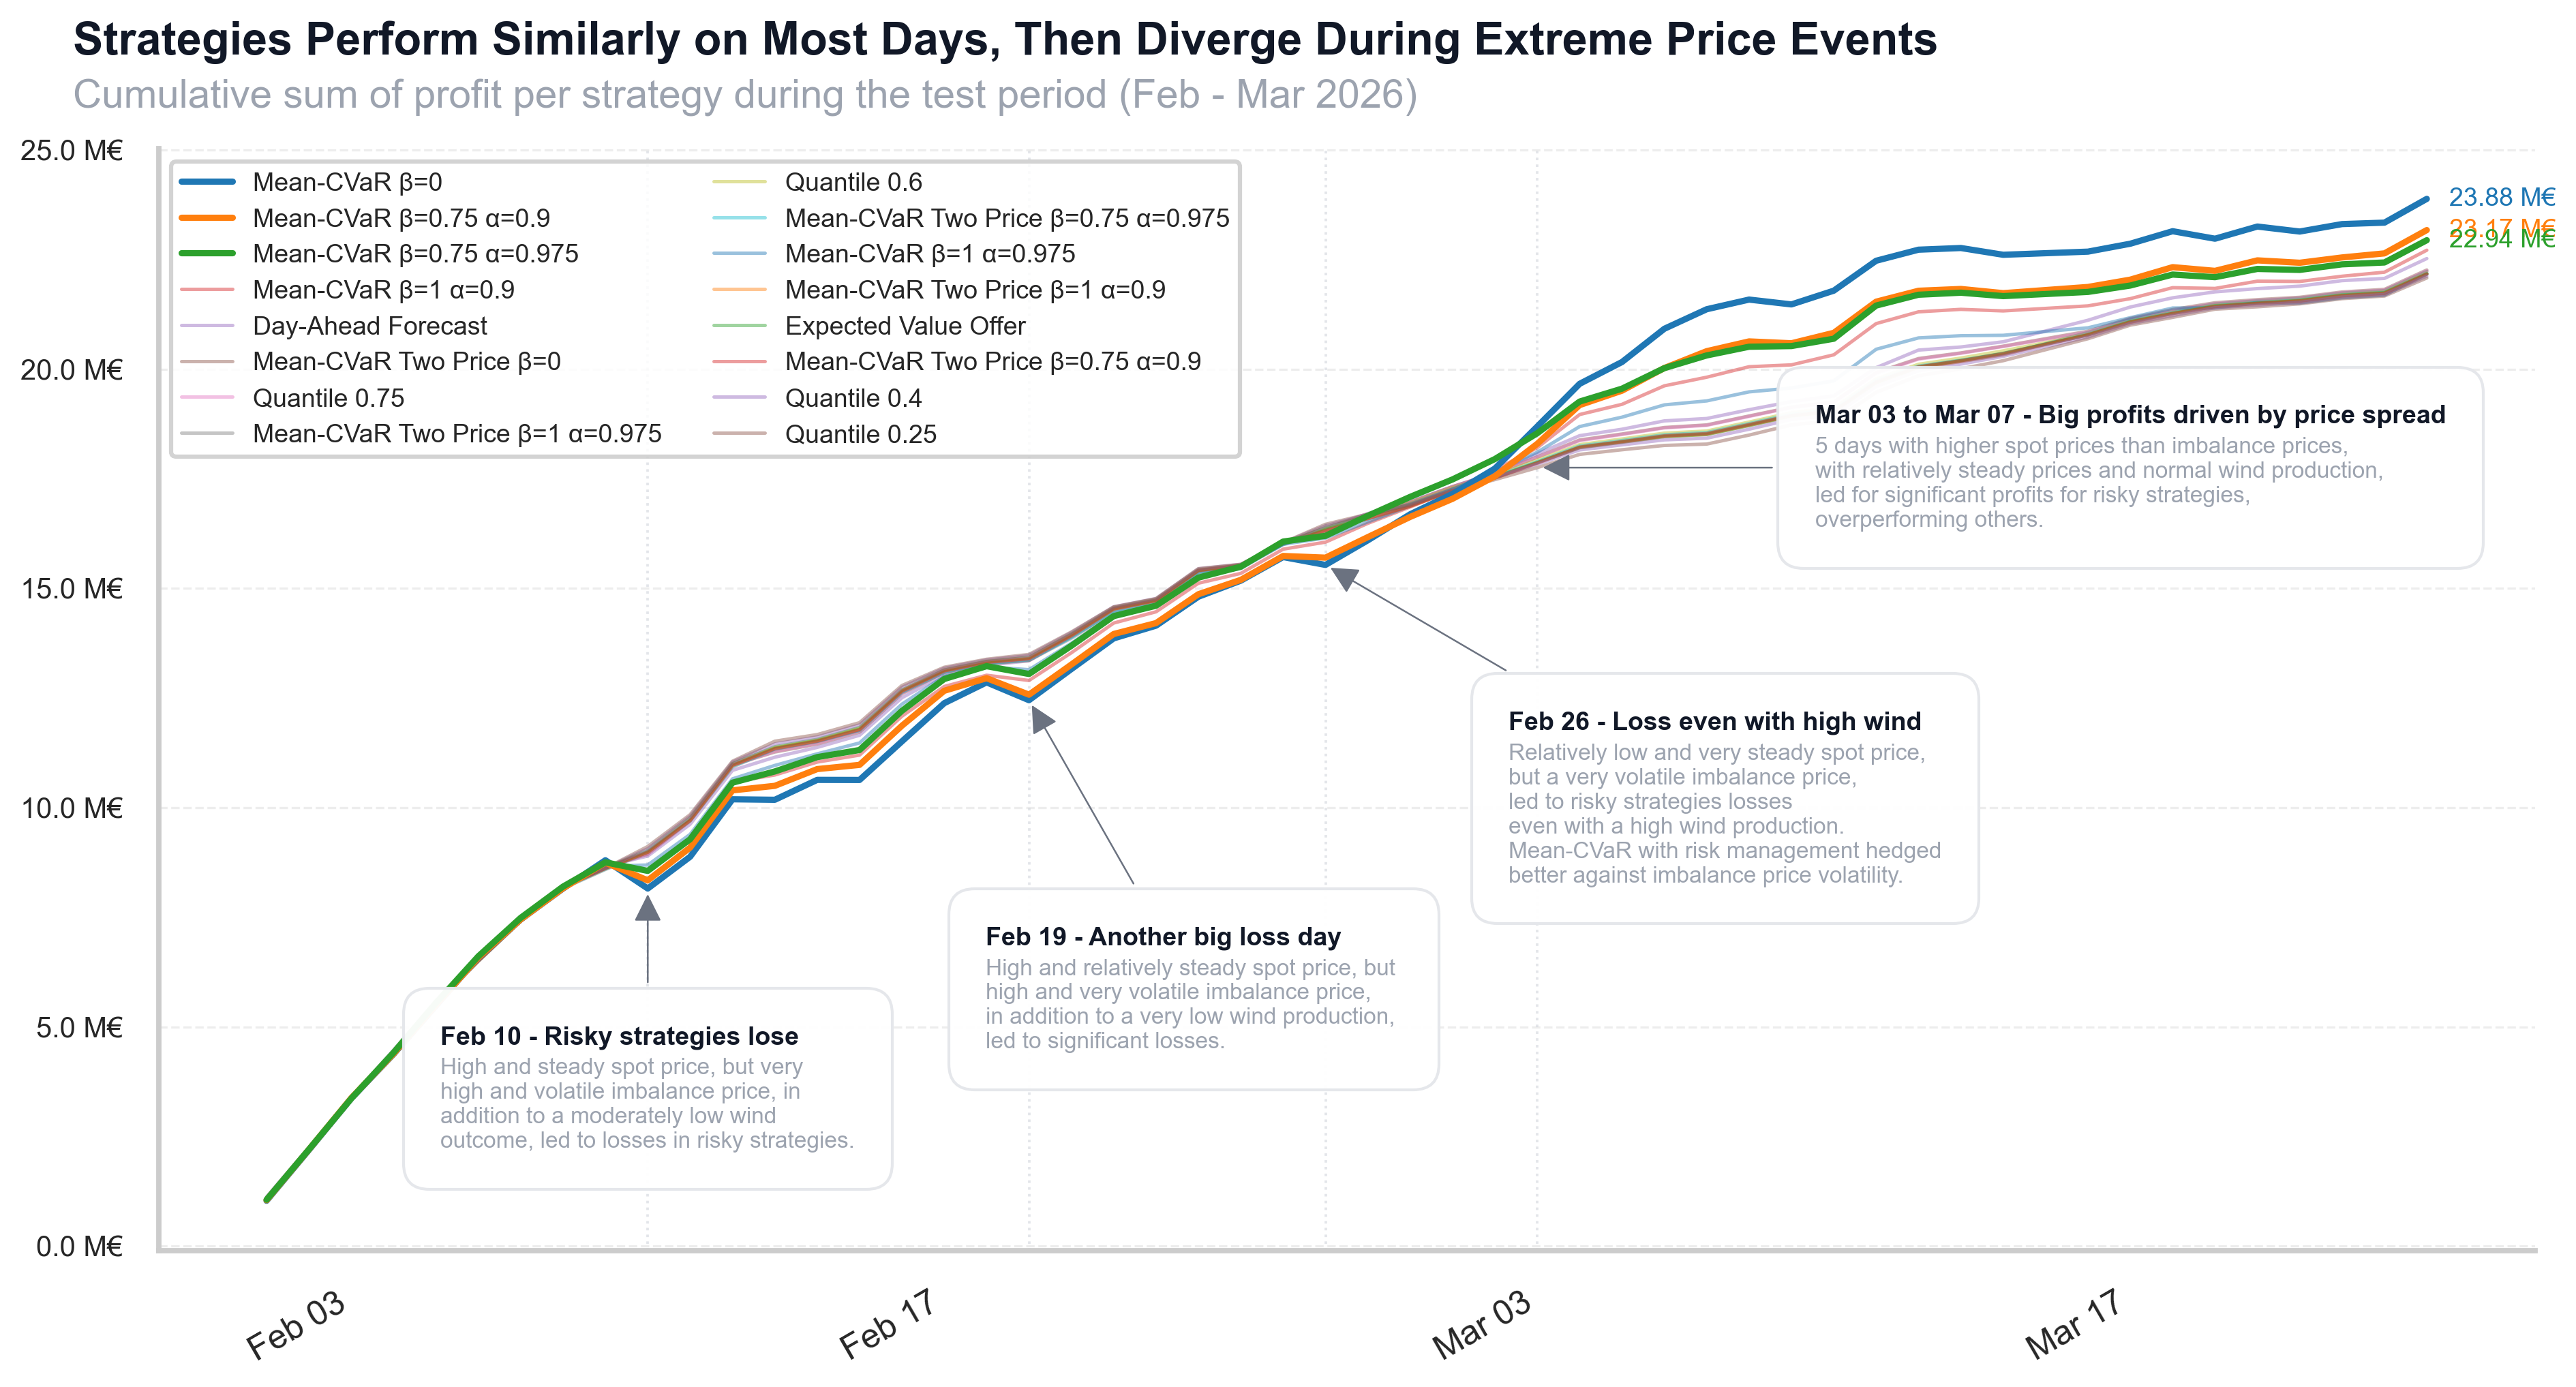

In [120]:
TITLE = "Strategies Perform Similarly on Most Days, Then Diverge During Extreme Price Events"
SUBTITLE = "Cumulative sum of profit per strategy during the test period (Feb - Mar 2026)"

EVENTS = [
    {
        "date": "2026-02-10",
        "title": "Feb 10 - Risky strategies lose",
        "description": "High and steady spot price, but very\n"
        "high and volatile imbalance price, in\n"
        "addition to a moderately low wind\n"
        "outcome, led to losses in risky strategies.",
    },
    {
        "date": "2026-02-19",
        "title": "Feb 19 - Another big loss day",
        "description": "High and relatively steady spot price, but\n"
        "high and very volatile imbalance price, \n"
        "in addition to a very low wind production, \n"
        "led to significant losses.",
    },
    {
        "date": "2026-02-26",
        "title": "Feb 26 - Loss even with high wind",
        "description": "Relatively low and very steady spot price,\n"
        "but a very volatile imbalance price, \n"
        "led to risky strategies losses \n"
        "even with a high wind production.\n"
        "Mean-CVaR with risk management hedged\n"
        "better against imbalance price volatility.",
    },
    {
        "date": "2026-03-03",
        "title": "Mar 03 to Mar 07 - Big profits driven by price spread",
        "description": "5 days with higher spot prices than imbalance prices, \n"
        "with relatively steady prices and normal wind production, \n"
        "led for significant profits for risky strategies, \n"
        "overperforming others.",
    },
]
# Plot cumulative profit per strategy over time
import matplotlib.dates as mdates
from matplotlib.offsetbox import TextArea, VPacker, AnnotationBbox

cum_by_strat = {
    strategy_id: (
        df_results[df_results["strategy_id"] == strategy_id]
        .sort_values("date")
        .set_index("date")["profit_real"]
        .cumsum()
    )
    for strategy_id in df_results["strategy_id"].unique()
}
all_cum_vals = np.concatenate([values.values for values in cum_by_strat.values()])
y_range = all_cum_vals.max() - all_cum_vals.min()

# Compute x-range and aspect scale so the arrow diagonal matches the visual aspect ratio
_x_dates = df_results["date"].sort_values()
x_range = _x_dates.max() - _x_dates.min()  # Timedelta

_fig_w, _fig_h = 14, 7
_ax_w_frac = 0.93 - 0.10   # from subplots_adjust right - left
_ax_h_frac = 0.88 - 0.12   # approx top - bottom
aspect_scale = (_fig_w * _ax_w_frac) / (_fig_h * _ax_h_frac)

def add_callout(ax, arrow_xy, box_xy, title, description):
    title_area = TextArea(
        title,
        textprops=dict(fontsize=9, fontweight="bold", color="#111827"),
    )
    body_area = TextArea(
        description,
        textprops=dict(fontsize=8, color="#9CA3AF"),
    )
    packed = VPacker(children=[title_area, body_area], pad=4, sep=3, align="left")

    annotation_box = AnnotationBbox(
        packed,
        arrow_xy,
        xybox=box_xy,
        xycoords="data",
        boxcoords="data",
        box_alignment=(0.5, 0.5),
        bboxprops=dict(
            boxstyle="round,pad=0.55",
            fc="white",
            ec="#E5E7EB",
            lw=1.0,
            alpha=0.97,
        ),
        arrowprops=dict(
            arrowstyle="-|>",
            color="#6B7280",
            lw=0.6,
            mutation_scale=5,
            connectionstyle="arc3,rad=0.0",
        ),
        zorder=9,
    )
    ax.add_artist(annotation_box)

sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(14, 7), dpi=300)

n_strategies = df_results["strategy_id"].nunique()
palette = sns.color_palette("tab10", n_strategies)

strategy_order = (
    df_results.groupby("strategy_id")["profit_real"]
    .sum()
    .sort_values(ascending=False)
    .index
)

for index, strategy_id in enumerate(strategy_order):
    group = df_results[df_results["strategy_id"] == strategy_id].sort_values("date")
    cumulative_profit = group["profit_real"].cumsum()
    label = group["label"].iloc[0]

    ax.plot(
        group["date"],
        cumulative_profit,
        label=label,
        color=palette[index],
        linewidth=2.2 if index < 3 else 1.2,
        alpha=1.0 if index < 3 else 0.45,
        zorder=3 if index < 3 else 2,
    )

    if index < 3:
        final_val = cumulative_profit.iloc[-1]
        ax.annotate(
            f"{final_val/1e6:.2f} M€",
            xy=(group["date"].iloc[-1], final_val),
            xytext=(8, 0),
            textcoords="offset points",
            va="center",
            fontsize=9,
            color=palette[index],
        )

valid_events = []
for event in EVENTS:
    event_date = pd.to_datetime(event["date"], errors="coerce")
    if pd.notna(event_date):
        valid_events.append({**event, "date": event_date})

n_events = len(valid_events)

for index, event in enumerate(valid_events):
    event_date = event["date"]

    y_candidates = [
        cumulative_series.loc[event_date]
        for cumulative_series in cum_by_strat.values()
        if event_date in cumulative_series.index
    ]
    if y_candidates:
        y_anchor = float(np.min(y_candidates))
    else:
        y_anchor = float(np.median(all_cum_vals))

    # t=0 → vertical (first), t=1 → horizontal (last), linear transition in between
    t = index / max(n_events - 1, 1)
    theta = t * (np.pi / 2)

    # Arrow length increases for later (more horizontal) events because the box width
    # reduces the visible portion of horizontal arrows more than for vertical ones.
    arrow_len = 0.2 + 0.4 * t

    # In data coordinates, a uniform visual length arrow at angle theta from vertical:
    #   Δy = -arrow_len * cos(theta) * y_range          (downward)
    #   Δx = arrow_len * sin(theta) * x_range / aspect_scale  (rightward)
    dy = -arrow_len * np.cos(theta) * y_range
    dx = arrow_len * np.sin(theta) * x_range / aspect_scale

    box_x = event_date + dx
    box_y = y_anchor + dy

    add_callout(
        ax,
        arrow_xy=(event_date, y_anchor),
        box_xy=(box_x, box_y),
        title=event["title"],
        description=event["description"],
    )
    ax.axvline(event_date, color="#D1D5DB", lw=0.9, ls=":", zorder=1, alpha=0.6)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=12)

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1e6:.1f} M€"))
ax.tick_params(axis="y", labelsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.35)
ax.grid(axis="x", visible=False)
ax.legend(loc="upper left", fontsize=9, framealpha=0.85, ncol=2)

fig.text(
    0.07,
    0.97,
    TITLE,
    ha="left",
    va="top",
    fontsize=16,
    fontweight="bold",
    color="#111827",
)
fig.text(
    0.07,
    0.93,
    SUBTITLE,
    ha="left",
    va="top",
    fontsize=14,
    color="#9CA3AF",
)

fig.subplots_adjust(top=0.88, right=0.93, left=0.10)
plt.show()


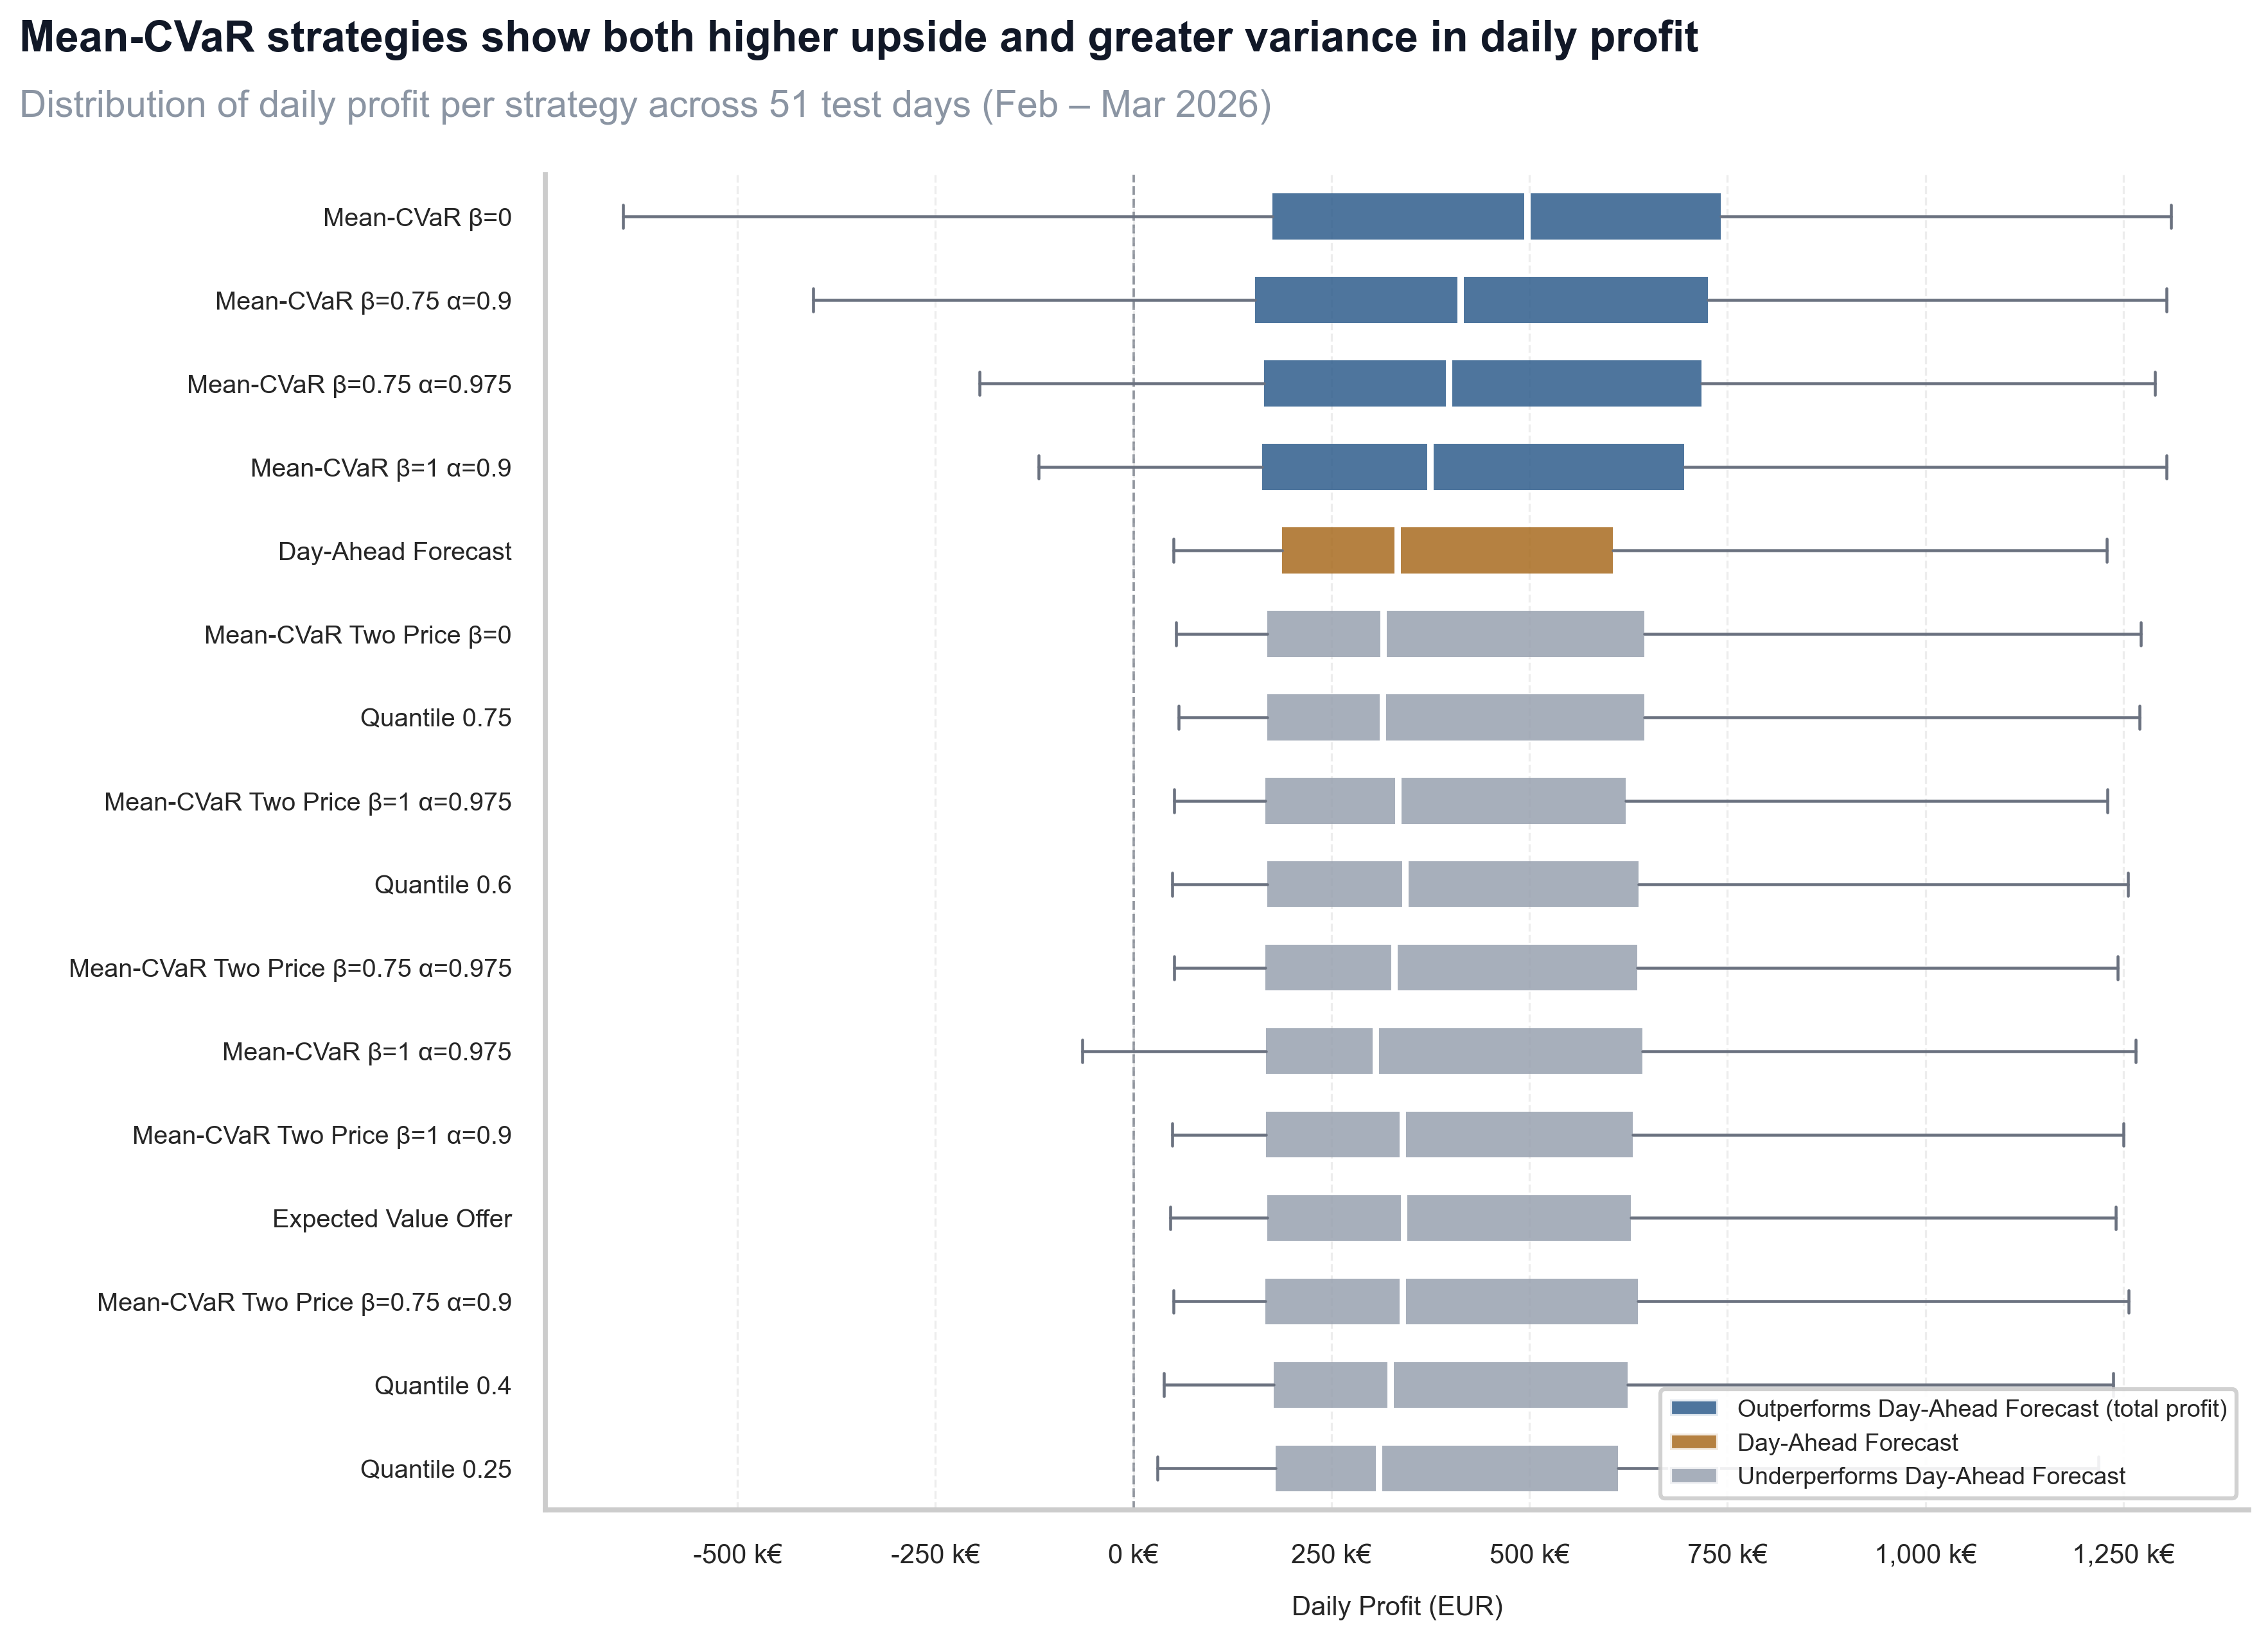

In [ ]:

from matplotlib.patches import Patch

TITLE = "Mean-CVaR strategies show both higher upside and greater variance in daily profit"
SUBTITLE = "Distribution of daily profit per strategy across 51 test days (Feb – Mar 2026)"

sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(13, 9), dpi=300)

# Sort by total profit ascending → highest ends up at the top of the y-axis
strategy_order = (
    df_results.groupby("strategy_id")["profit_real"]
    .sum()
    .sort_values(ascending=True)
    .index.tolist()
)

label_map = (
    df_results[["strategy_id", "label"]]
    .drop_duplicates()
    .set_index("strategy_id")["label"]
)
ordered_labels = [label_map[s] for s in strategy_order]

# Color coding consistent with the bar chart above
base_color      = "#98A1AF"
highlight_color = "#2F5D8C"
day_ahead_color = "#A86B1F"

total_profits  = df_results.groupby("strategy_id")["profit_real"].sum()
day_ahead_id   = df_results[df_results["label"].str.contains("Day-Ahead Forecast", na=False)]["strategy_id"].iloc[0]
day_ahead_total = total_profits[day_ahead_id]

colors = []
for s in strategy_order:
    lbl = label_map[s]
    if "Day-Ahead Forecast" in lbl:
        colors.append(day_ahead_color)
    elif total_profits[s] > day_ahead_total:
        colors.append(highlight_color)
    else:
        colors.append(base_color)

data_list = [df_results[df_results["strategy_id"] == s]["profit_real"].values for s in strategy_order]

bp = ax.boxplot(
    data_list,
    vert=False,
    patch_artist=True,
    notch=False,
    widths=0.55,
    medianprops=dict(color="white", linewidth=2.4),
    whiskerprops=dict(linewidth=1.1, color="#6B7280"),
    capprops=dict(linewidth=1.1, color="#6B7280"),
    flierprops=dict(marker="o", markersize=4, linestyle="none", alpha=0.55),
    boxprops=dict(linewidth=0),
    zorder=3,
)

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

for flier, color in zip(bp["fliers"], colors):
    flier.set(markerfacecolor=color, markeredgecolor=color)

ax.set_yticks(range(1, len(ordered_labels) + 1))
ax.set_yticklabels(ordered_labels, fontsize=9.5)

ax.set_xlabel("Daily Profit (EUR)", labelpad=10, fontsize=10)
ax.tick_params(axis="x", labelsize=10)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1e3:,.0f} k€"))

# Zero reference line
ax.axvline(0, color="#374151", linewidth=0.9, linestyle="--", alpha=0.5, zorder=2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="--", linewidth=0.8, alpha=0.35, zorder=0)
ax.grid(axis="y", visible=False)

legend_elements = [
    Patch(facecolor=highlight_color, alpha=0.85, label="Outperforms Day-Ahead Forecast (total profit)"),
    Patch(facecolor=day_ahead_color, alpha=0.85, label="Day-Ahead Forecast"),
    Patch(facecolor=base_color,      alpha=0.85, label="Underperforms Day-Ahead Forecast"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9, framealpha=0.9)

fig.text(0.07, 0.97, TITLE,    ha="left", va="top", fontsize=16, fontweight="bold", color="#111827")
fig.text(0.07, 0.93, SUBTITLE, ha="left", va="top", fontsize=14, color="#8B95A3")

fig.subplots_adjust(top=0.88, right=0.96, left=0.28)
plt.show()


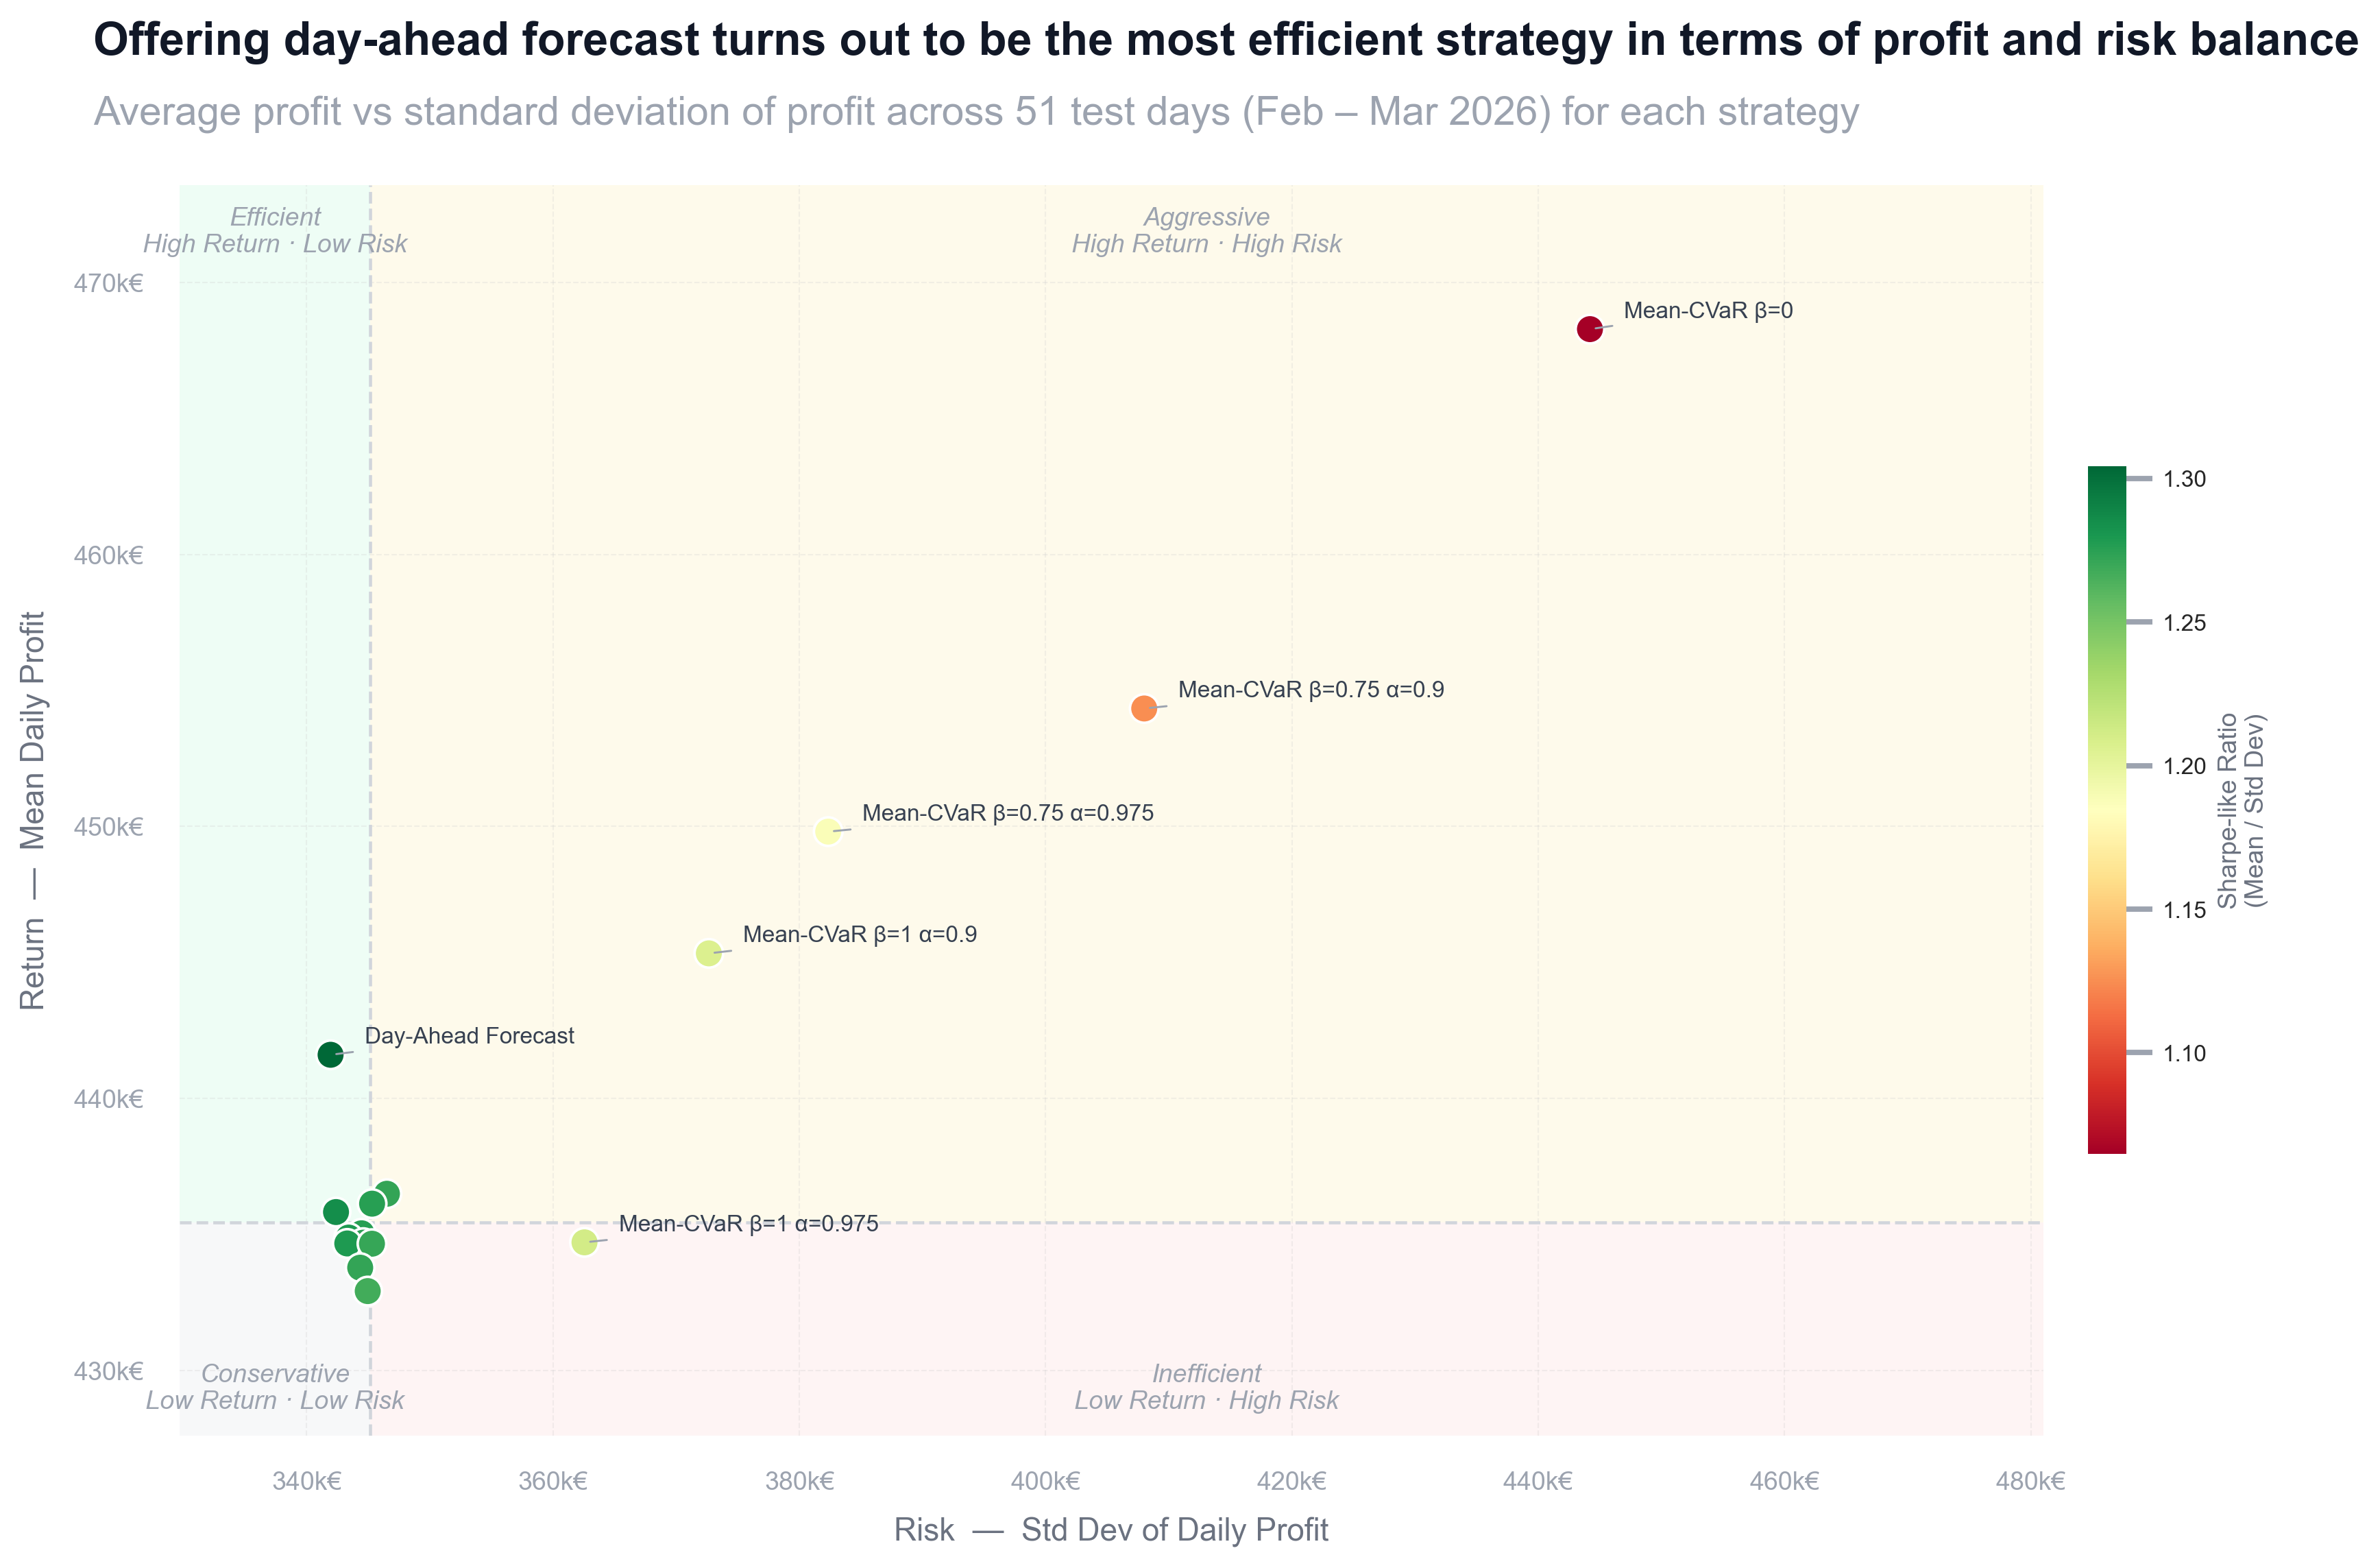

In [113]:
TITLE = "Offering day-ahead forecast turns out to be the most efficient strategy in terms of profit and risk balance"
SUBTITLE = "Average profit vs standard deviation of profit across 51 test days (Feb – Mar 2026) for each strategy"

# --- Data prep ---
df_scatter = result_summary.reset_index().copy()
df_scatter["mean_k"] = df_scatter["mean_profit"] / 1000
df_scatter["std_k"]  = df_scatter["stdev_profit"] / 1000

# Quadrant split at median
x_mid = df_scatter["std_k"].median()
y_mid = df_scatter["mean_k"].median()

# --- Layout ---
sns.set_theme(style="white", context="talk")
fig, ax = plt.subplots(figsize=(14, 8), dpi=300)

# Axis limits with padding (extra right for end-of-line labels)
px = (df_scatter["std_k"].max() - df_scatter["std_k"].min()) * 0.12
py = (df_scatter["mean_k"].max() - df_scatter["mean_k"].min()) * 0.15
xlim = (df_scatter["std_k"].min() - px, df_scatter["std_k"].max() + px * 3.0)
ylim = (df_scatter["mean_k"].min() - py, df_scatter["mean_k"].max() + py)
ax.set_xlim(xlim); ax.set_ylim(ylim)

# --- Quadrant shading ---
ax.fill_between([xlim[0], x_mid], y_mid, ylim[1], color="#D1FAE5", alpha=0.35, zorder=0, lw=0)  # efficient
ax.fill_between([x_mid, xlim[1]], y_mid, ylim[1], color="#FEF3C7", alpha=0.35, zorder=0, lw=0)  # aggressive
ax.fill_between([xlim[0], x_mid], ylim[0], y_mid, color="#F3F4F6", alpha=0.60, zorder=0, lw=0)  # conservative
ax.fill_between([x_mid, xlim[1]], ylim[0], y_mid, color="#FEE2E2", alpha=0.35, zorder=0, lw=0)  # inefficient

ax.axvline(x_mid, color="#D1D5DB", lw=1.1, ls="--", zorder=1)
ax.axhline(y_mid, color="#D1D5DB", lw=1.1, ls="--", zorder=1)

# Quadrant labels
ql = dict(fontsize=9, color="#9CA3AF", fontstyle="italic", ha="center", zorder=2)
q_y_top = ylim[1] - py * 0.15
q_y_bot = ylim[0] + py * 0.15
ax.text((xlim[0] + x_mid) / 2, q_y_top, "Efficient\nHigh Return · Low Risk",    va="top",    **ql)
ax.text((x_mid + xlim[1]) / 2, q_y_top, "Aggressive\nHigh Return · High Risk",  va="top",    **ql)
ax.text((xlim[0] + x_mid) / 2, q_y_bot, "Conservative\nLow Return · Low Risk",  va="bottom", **ql)
ax.text((x_mid + xlim[1]) / 2, q_y_bot, "Inefficient\nLow Return · High Risk",  va="bottom", **ql)

# --- Scatter colored by Sharpe-like ratio ---
norm = plt.Normalize(df_scatter["profit_to_risk"].min(), df_scatter["profit_to_risk"].max())
cmap = plt.cm.RdYlGn

sc = ax.scatter(
    df_scatter["std_k"], df_scatter["mean_k"],
    c=df_scatter["profit_to_risk"], cmap=cmap, norm=norm,
    s=100, edgecolor="white", linewidth=0.9, zorder=5,
)

# Colorbar
cbar = fig.colorbar(sc, ax=ax, pad=0.02, shrink=0.55, aspect=18)
cbar.set_label("Sharpe-like Ratio\n(Mean / Std Dev)", fontsize=9, color="#6B7280")
cbar.ax.tick_params(labelsize=8, color="#9CA3AF")
cbar.outline.set_visible(False)

# --- Label outliers (most isolated points — largest nearest-neighbor distance) ---
coords = df_scatter[["std_k", "mean_k"]].values
coords_norm = (coords - coords.mean(axis=0)) / coords.std(axis=0)

nn_dists = []
for i in range(len(coords_norm)):
    dists = np.sqrt(((coords_norm - coords_norm[i]) ** 2).sum(axis=1))
    dists[i] = np.inf
    nn_dists.append(dists.min())

df_scatter["nn_dist"] = nn_dists

for _, row in df_scatter.nlargest(6, "nn_dist").iterrows():
    ax.annotate(
        row["label"],
        xy=(row["std_k"], row["mean_k"]),
        xytext=(12, 4), textcoords="offset points",
        fontsize=8, color="#374151",
        arrowprops=dict(arrowstyle="-", color="#9CA3AF", lw=0.7),
        zorder=6,
    )

# --- Axis formatting ---
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}k€"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}k€"))
ax.set_xlabel("Risk  —  Std Dev of Daily Profit", labelpad=8, color="#6B7280", fontsize=11)
ax.set_ylabel("Return  —  Mean Daily Profit", labelpad=8, color="#6B7280", fontsize=11)
ax.tick_params(colors="#9CA3AF", labelsize=9)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(axis="both", ls="--", lw=0.5, alpha=0.25, zorder=1)

# --- Title + subtitle (left-aligned) ---
fig.text(0.07, 0.97, TITLE,
         ha="left", va="top", fontsize=16, fontweight="bold", color="#111827")
fig.text(0.07, 0.925,
         SUBTITLE,
         ha="left", va="top", fontsize=14, color="#9CA3AF")

fig.subplots_adjust(top=0.87, right=0.88, left=0.10)
plt.show()

In [121]:
# check the mean imbalance exposure per strategy, to see if the more profitable strategies are also those with higher imbalance exposure
result_summary[["label", "mean_exposure_to_imbalance", "mean_profit"]].sort_values("mean_exposure_to_imbalance", ascending=False)

,label,mean_exposure_to_imbalance,mean_profit
0,Mean-CVaR β=0,68.255663,468294.271033
1,Mean-CVaR β=0.75 α=0.9,52.016887,454340.932620
2,Mean-CVaR β=0.75 α=0.975,34.473552,449811.652181
3,Mean-CVaR β=1 α=0.9,32.730652,445334.396053
10,Mean-CVaR β=1 α=0.975,23.242669,434705.162690
5,Mean-CVaR Two Price β=0,6.806771,436492.416925
13,Mean-CVaR Two Price β=0.75 α=0.9,6.670425,434654.535404
7,Mean-CVaR Two Price β=1 α=0.975,6.653732,435819.086493
9,Mean-CVaR Two Price β=0.75 α=0.975,6.586876,434880.826912
6,Quantile 0.75,6.441441,436127.485958
